In [92]:
# =========================
# STEP 1A: Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

from sklearn.metrics import (
    mean_squared_error,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

import warnings
warnings.filterwarnings("ignore")

In [93]:
from google.colab import files
uploaded = files.upload()

# pick the first uploaded file name automatically
file_name = list(uploaded.keys())[0]
print("Loaded file:", file_name)

df = pd.read_csv(file_name)
df.head()

Saving student_performance.csv to student_performance (4).csv
Loaded file: student_performance (4).csv


,Timestamp,Username,Current CGPA,Attendance percentage,No of backlogs(if any),Study hours per day,Coding practice hours per week,When do you usually complete assessments?,Sleep hours per day,Social media usage per day,Stress level during semester,Motivation level,Expected final grade,Do you feel placement ready?,Exam preparation style
0,2026/02/28 1:01:11 PM GMT+5:30,khushboo3045.beai24@chitkara.edu.in,9.03,65,No,3,6,Immediately after assigned,9,7,3,4,9+,Not sure,Regular study
1,2026/02/28 2:16:24 PM GMT+5:30,khushboo2006june@gmail.com,8.00,96,Yes,2,4,Immediately after assigned,10,10,2,2,7-8.5,Not sure,Regular study
2,2026/02/28 2:21:20 PM GMT+5:30,NaN,8.48,Average 85%,0,1-2 per day,2 or 3 hours,On deadline day,6-7,5-6,4,2,9+,No,One week before exams
3,2026/02/28 2:38:51 PM GMT+5:30,NaN,7.80,65,1,2-3,10-12,Few days before deadline,7-8,5-6,4,2,8.5+,No,One week before exams
4,2026/02/28 2:48:43 PM GMT+5:30,NaN,9.28,80%,0,2,10,Few days before deadline,6,4,4,3,9+,Not sure,One week before exams


In [94]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nInfo:")
display(df.info())

print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nFirst 5 rows:")
display(df.head())

Shape: (500, 15)

Columns:
 Index(['Timestamp', 'Username', 'Current CGPA ', 'Attendance percentage ',
       'No of backlogs(if any)', 'Study hours per day',
       'Coding practice hours per week',
       'When do you usually complete assessments? ', 'Sleep hours per day',
       'Social media usage per day', 'Stress level during semester',
       'Motivation level', 'Expected final grade',
       'Do you feel placement ready? ', 'Exam preparation style'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Timestamp                                   500 non-null    object 
 1   Username                                    2 non-null      object 
 2   Current CGPA                                500 non-null    float64
 3   Attendance percentage            

None


Missing values per column:


,0
Username,498
No of backlogs(if any),1
Timestamp,0
Current CGPA,0
Attendance percentage,0
Study hours per day,0
Coding practice hours per week,0
When do you usually complete assessments?,0
Sleep hours per day,0
Social media usage per day,0



First 5 rows:


,Timestamp,Username,Current CGPA,Attendance percentage,No of backlogs(if any),Study hours per day,Coding practice hours per week,When do you usually complete assessments?,Sleep hours per day,Social media usage per day,Stress level during semester,Motivation level,Expected final grade,Do you feel placement ready?,Exam preparation style
0,2026/02/28 1:01:11 PM GMT+5:30,khushboo3045.beai24@chitkara.edu.in,9.03,65,No,3,6,Immediately after assigned,9,7,3,4,9+,Not sure,Regular study
1,2026/02/28 2:16:24 PM GMT+5:30,khushboo2006june@gmail.com,8.00,96,Yes,2,4,Immediately after assigned,10,10,2,2,7-8.5,Not sure,Regular study
2,2026/02/28 2:21:20 PM GMT+5:30,NaN,8.48,Average 85%,0,1-2 per day,2 or 3 hours,On deadline day,6-7,5-6,4,2,9+,No,One week before exams
3,2026/02/28 2:38:51 PM GMT+5:30,NaN,7.80,65,1,2-3,10-12,Few days before deadline,7-8,5-6,4,2,8.5+,No,One week before exams
4,2026/02/28 2:48:43 PM GMT+5:30,NaN,9.28,80%,0,2,10,Few days before deadline,6,4,4,3,9+,Not sure,One week before exams


In [95]:
# Drop unnecessary columns
df = df.drop(columns=["Timestamp", "Username"])

print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['Current CGPA ', 'Attendance percentage ', 'No of backlogs(if any)',
       'Study hours per day', 'Coding practice hours per week',
       'When do you usually complete assessments? ', 'Sleep hours per day',
       'Social media usage per day', 'Stress level during semester',
       'Motivation level', 'Expected final grade',
       'Do you feel placement ready? ', 'Exam preparation style'],
      dtype='object')


In [96]:
# Clean Attendance percentage
df["Attendance percentage "] = (
    df["Attendance percentage "]
    .astype(str)
    .str.extract(r'(\d+)')  # extract numbers only
    .astype(float)
)

print("Attendance cleaned sample:")
display(df["Attendance percentage "].head())

Attendance cleaned sample:


,Attendance percentage
0,65.0
1,96.0
2,85.0
3,65.0
4,80.0


In [97]:
# Clean backlogs
df["No of backlogs(if any)"] = df["No of backlogs(if any)"].fillna("0")

df["No of backlogs(if any)"] = df["No of backlogs(if any)"].replace({
    "No": "0",
    "Yes": "1"
})

df["No of backlogs(if any)"] = df["No of backlogs(if any)"].astype(str).str.extract(r'(\d+)').astype(float)

display(df["No of backlogs(if any)"].head())

,No of backlogs(if any)
0,0.0
1,1.0
2,0.0
3,1.0
4,0.0


In [98]:
def extract_average(value):
    value = str(value)
    nums = [int(s) for s in value.split() if s.isdigit()]

    if len(nums) == 0:
        nums = list(map(int, filter(str.isdigit, value.replace('-', ' ').split())))

    if len(nums) == 0:
        return np.nan

    return np.mean(nums)

df["Study hours per day"] = df["Study hours per day"].apply(extract_average)

display(df["Study hours per day"].head())

,Study hours per day
0,3.0
1,2.0
2,1.5
3,2.5
4,2.0


In [99]:
cols_to_clean = [
    "Coding practice hours per week",
    "Sleep hours per day",
    "Social media usage per day"
]

for col in cols_to_clean:
    df[col] = df[col].apply(extract_average)

display(df[cols_to_clean].head())

,Coding practice hours per week,Sleep hours per day,Social media usage per day
0,6.0,9.0,7.0
1,4.0,10.0,10.0
2,2.5,6.5,5.5
3,11.0,7.5,5.5
4,10.0,6.0,4.0


In [100]:
df = df.rename(columns={
    "Current CGPA ": "cgpa",
    "Attendance percentage ": "attendance",
    "No of backlogs(if any)": "backlogs",
    "Study hours per day": "study_hours",
    "Coding practice hours per week": "coding_hours",
    "Sleep hours per day": "sleep_hours",
    "Social media usage per day": "social_media_hours",
    "Stress level during semester": "stress",
    "Motivation level": "motivation",
    "Expected final grade": "expected_grade",
    "Do you feel placement ready? ": "placement_ready",
    "Exam preparation style": "prep_style",
    "When do you usually complete assessments? ": "assessment_timing"
})

print(df.columns)

Index(['cgpa', 'attendance', 'backlogs', 'study_hours', 'coding_hours',
       'assessment_timing', 'sleep_hours', 'social_media_hours', 'stress',
       'motivation', 'expected_grade', 'placement_ready', 'prep_style'],
      dtype='object')


In [101]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cgpa                500 non-null    float64
 1   attendance          494 non-null    float64
 2   backlogs            497 non-null    float64
 3   study_hours         490 non-null    float64
 4   coding_hours        495 non-null    float64
 5   assessment_timing   500 non-null    object 
 6   sleep_hours         496 non-null    float64
 7   social_media_hours  492 non-null    float64
 8   stress              500 non-null    int64  
 9   motivation          500 non-null    int64  
 10  expected_grade      500 non-null    object 
 11  placement_ready     500 non-null    object 
 12  prep_style          500 non-null    object 
dtypes: float64(7), int64(2), object(4)
memory usage: 50.9+ KB


,cgpa,attendance,backlogs,study_hours,coding_hours,sleep_hours,social_media_hours,stress,motivation
count,500.000000,494.000000,497.000000,490.000000,495.000000,496.000000,492.000000,500.000000,500.000000
mean,8.179620,78.738866,0.517103,4.348980,10.609091,7.080645,2.974593,3.102000,3.240000
std,0.896677,10.998369,0.783016,2.477227,22.068288,1.362391,1.647335,1.435171,1.379204
min,6.050000,43.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,7.577500,70.000000,0.000000,2.000000,5.000000,6.000000,2.000000,2.000000,2.000000
50%,8.055000,79.000000,0.000000,4.000000,8.000000,7.000000,3.000000,3.000000,3.000000
75%,8.960000,88.000000,1.000000,6.000000,14.000000,8.000000,4.000000,4.000000,5.000000
max,10.000000,100.000000,7.000000,24.000000,480.000000,10.000000,10.000000,5.000000,5.000000


In [102]:
numeric_cols = [
    "attendance",
    "backlogs",
    "study_hours",
    "coding_hours",
    "sleep_hours",
    "social_media_hours"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
cgpa                  0
attendance            0
backlogs              0
study_hours           0
coding_hours          0
assessment_timing     0
sleep_hours           0
social_media_hours    0
stress                0
motivation            0
expected_grade        0
placement_ready       0
prep_style            0
dtype: int64


In [103]:
# Study Efficiency
df["study_efficiency"] = df["study_hours"] / (df["social_media_hours"] + 1)

# Sleep Balance (distance from ideal 7 hours)
df["sleep_balance"] = abs(df["sleep_hours"] - 7)

# Academic Consistency
df["academic_consistency"] = df["attendance"] * df["study_hours"]

# Stress Index
df["stress_index"] = df["stress"] / (df["sleep_hours"] + 1)

print("New columns added:")
print(df.columns)

New columns added:
Index(['cgpa', 'attendance', 'backlogs', 'study_hours', 'coding_hours',
       'assessment_timing', 'sleep_hours', 'social_media_hours', 'stress',
       'motivation', 'expected_grade', 'placement_ready', 'prep_style',
       'study_efficiency', 'sleep_balance', 'academic_consistency',
       'stress_index'],
      dtype='object')


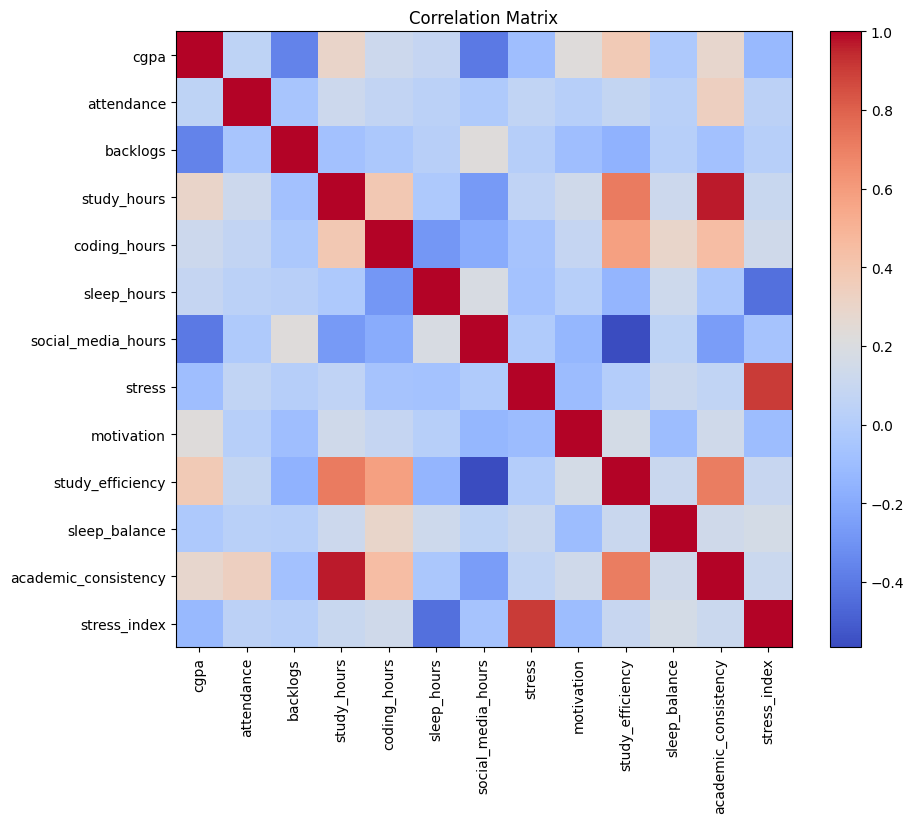

,cgpa
cgpa,1.000000
study_efficiency,0.375390
study_hours,0.297980
academic_consistency,0.282334
motivation,0.227811
coding_hours,0.123885
sleep_hours,0.087269
attendance,0.054319
sleep_balance,-0.024935
stress,-0.091568


In [104]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

corr["cgpa"].sort_values(ascending=False)

In [105]:
# ==============================
# OUTLIER TREATMENT (IQR CAPPING)
# ==============================

def cap_outliers_iqr(df, numeric_columns):
    df_out = df.copy()

    for col in numeric_columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values instead of removing
        df_out[col] = df_out[col].clip(lower=lower_bound, upper=upper_bound)

    return df_out


# Select all numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Apply outlier capping
df = cap_outliers_iqr(df, numeric_cols)

print("Outliers capped using IQR method.")

Outliers capped using IQR method.


In [106]:
# Feature and target
X_simple = df[["study_hours"]]
y = df["cgpa"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred = lin_reg.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Coefficient (slope):", lin_reg.coef_[0])
print("Intercept:", lin_reg.intercept_)
print("RMSE:", rmse)

Coefficient (slope): 0.11923743163275247
Intercept: 7.68618433018579
RMSE: 0.9333755956318255


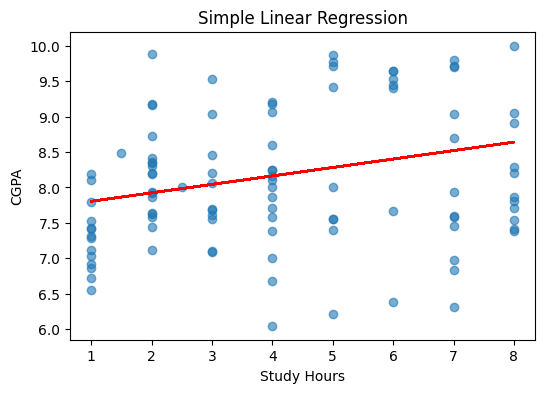

In [107]:
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, alpha=0.6)
plt.plot(X_test, y_pred, color="red")
plt.xlabel("Study Hours")
plt.ylabel("CGPA")
plt.title("Simple Linear Regression")
plt.show()

In [108]:
# Convert to numpy arrays
X = df["study_hours"].values
y = df["cgpa"].values

# Initialize parameters
m = 0  # slope
b = 0  # intercept

learning_rate = 0.01
epochs = 200

n = len(X)

losses = []

for epoch in range(epochs):

    # Predictions
    y_pred = m * X + b

    # Compute gradients
    dm = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    # Update parameters
    m = m - learning_rate * dm
    b = b - learning_rate * db

    # Compute loss
    loss = np.mean((y - y_pred)**2)
    losses.append(loss)

print("Final slope:", m)
print("Final intercept:", b)
print("Final loss:", losses[-1])

Final slope: 0.681469141006543
Final intercept: 4.5627430434524845
Final loss: 2.9276732581611915


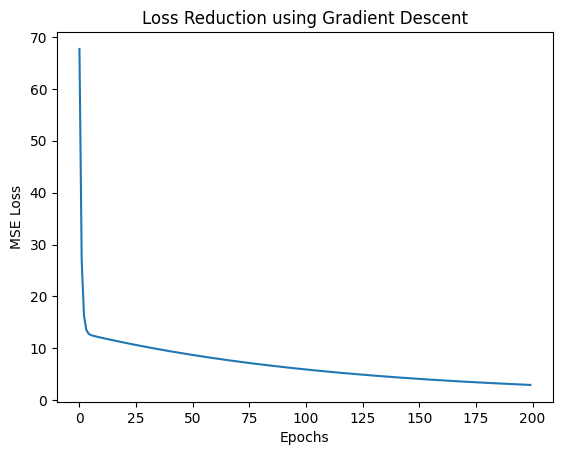

In [109]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss Reduction using Gradient Descent")
plt.show()

In [110]:
features = [
    "attendance",
    "study_hours",
    "coding_hours",
    "sleep_hours",
    "social_media_hours",
    "stress",
    "motivation",
    "backlogs",
    "study_efficiency",
    "sleep_balance",
    "academic_consistency",
    "stress_index"
]

X_multi = df[features]
y = df["cgpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)

print("Multiple Linear Regression RMSE:", rmse_multi)

Multiple Linear Regression RMSE: 0.8053005111535992


In [111]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X_multi)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train_p)

y_pred_poly = poly_model.predict(X_test_p)

mse_poly = mean_squared_error(y_test_p, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

print("Polynomial Regression RMSE:", rmse_poly)

Polynomial Regression RMSE: 0.8970353930953944


In [112]:
def grade_category(cgpa):
    if cgpa < 7:
        return "Below 7"
    elif cgpa < 8.5:
        return "7-8.5"
    elif cgpa < 9:
        return "8.5+"
    else:
        return "9+"

df["grade_category"] = df["cgpa"].apply(grade_category)

df["grade_category"].value_counts()

,count
grade_category,
7-8.5,314
9+,122
Below 7,33
8.5+,31


In [113]:
from sklearn.preprocessing import StandardScaler

X = df[features]
y = df["grade_category"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [114]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.7

Classification Report:

              precision    recall  f1-score   support

       7-8.5       0.69      0.94      0.80        63
        8.5+       0.00      0.00      0.00         6
          9+       0.73      0.46      0.56        24
     Below 7       0.00      0.00      0.00         7

    accuracy                           0.70       100
   macro avg       0.36      0.35      0.34       100
weighted avg       0.61      0.70      0.64       100



In [115]:
log_model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")

log_model_balanced.fit(X_train_scaled, y_train)

y_pred_bal = log_model_balanced.predict(X_test_scaled)

print("Balanced Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bal))

Balanced Accuracy: 0.41

Classification Report:

              precision    recall  f1-score   support

       7-8.5       0.71      0.38      0.49        63
        8.5+       0.09      0.33      0.14         6
          9+       0.57      0.54      0.55        24
     Below 7       0.10      0.29      0.14         7

    accuracy                           0.41       100
   macro avg       0.36      0.39      0.33       100
weighted avg       0.59      0.41      0.46       100



In [116]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.71

Classification Report:

              precision    recall  f1-score   support

       7-8.5       0.70      0.95      0.81        63
        8.5+       0.00      0.00      0.00         6
          9+       0.79      0.46      0.58        24
     Below 7       0.00      0.00      0.00         7

    accuracy                           0.71       100
   macro avg       0.37      0.35      0.35       100
weighted avg       0.63      0.71      0.65       100



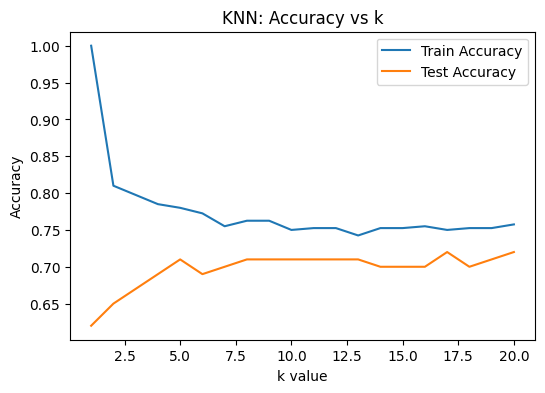

In [117]:
train_acc = []
test_acc = []

k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_acc.append(knn.score(X_train_scaled, y_train))
    test_acc.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(6,4))
plt.plot(k_values, train_acc, label="Train Accuracy")
plt.plot(k_values, test_acc, label="Test Accuracy")
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.legend()
plt.title("KNN: Accuracy vs k")
plt.show()

In [118]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': range(1, 21)
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_knn.fit(X_train_scaled, y_train)

print("Best k:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

Best k: {'n_neighbors': 13}
Best CV Score: 0.7424999999999999


In [119]:
best_knn = grid_knn.best_estimator_

y_pred_best_knn = best_knn.predict(X_test_scaled)

print("Final Test Accuracy:", accuracy_score(y_test, y_pred_best_knn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_knn))

Final Test Accuracy: 0.71

Classification Report:

              precision    recall  f1-score   support

       7-8.5       0.70      0.97      0.81        63
        8.5+       0.00      0.00      0.00         6
          9+       0.77      0.42      0.54        24
     Below 7       0.00      0.00      0.00         7

    accuracy                           0.71       100
   macro avg       0.37      0.35      0.34       100
weighted avg       0.63      0.71      0.64       100



In [120]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": multi_model.coef_
})

coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

coef_df

,Feature,Coefficient
7,backlogs,-0.369768
8,study_efficiency,0.306605
11,stress_index,0.184223
1,study_hours,0.183707
3,sleep_hours,0.091332
4,social_media_hours,-0.079242
5,stress,-0.074746
6,motivation,0.059408
9,sleep_balance,-0.044013
0,attendance,0.011247


In [121]:
from sklearn.linear_model import Ridge

# Redefine X and y for the regression task, using the numerical 'cgpa'
X = df[features]
y = df["cgpa"]

# Re-split the data for regression
X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_ridge, y_train_ridge)

y_pred_ridge = ridge.predict(X_test_ridge)

rmse_ridge = np.sqrt(mean_squared_error(y_test_ridge, y_pred_ridge))

print("Ridge RMSE:", rmse_ridge)

Ridge RMSE: 0.8048903251631127


In [122]:
from sklearn.linear_model import Lasso

# Redefine X and y for the regression task, using the numerical 'cgpa'
X = df[features]
y = df["cgpa"]

# Re-split the data for regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso RMSE:", rmse_lasso)

Lasso RMSE: 0.805079468323969


In [123]:
from sklearn.neighbors import KNeighborsRegressor

# Scale features for KNN
scaler_reg = StandardScaler()
X_scaled = scaler_reg.fit_transform(df[features])

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_scaled, df["cgpa"], test_size=0.2, random_state=42
)

knn_reg = KNeighborsRegressor(n_neighbors=18)
knn_reg.fit(X_train_knn, y_train_knn)

y_pred_knn_reg = knn_reg.predict(X_test_knn)

rmse_knn_reg = np.sqrt(mean_squared_error(y_test_knn, y_pred_knn_reg))

print("KNN Regressor RMSE:", rmse_knn_reg)

KNN Regressor RMSE: 0.8038282880483035


In [124]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = [
    "attendance",
    "study_hours",
    "sleep_hours",
    "social_media_hours",
    "stress",
    "motivation",
    "backlogs"
]

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[cluster_features])

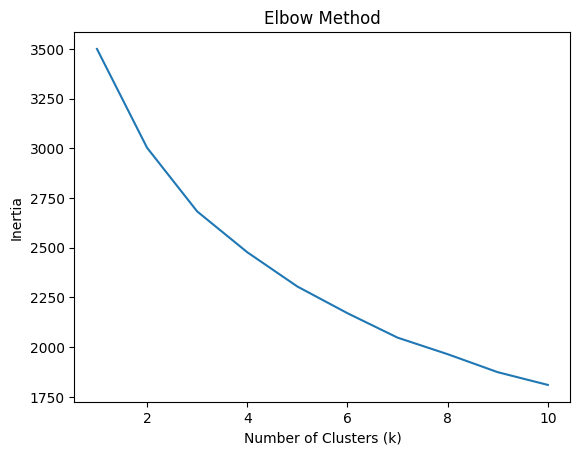

In [125]:
inertia = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [126]:
# Features already defined earlier as `features`
X = df[features].copy()

# classification target
y_cls = df["grade_category"].copy()

# regression target
y_reg = df["cgpa"].copy()

In [127]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 5, 10, 50],
    "clf__penalty": ["l2"],            # keep syllabus-simple
    "clf__solver": ["lbfgs"],          # supports multiclass well
}

grid_log = GridSearchCV(
    pipe_log,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",   # PRACTICAL metric for imbalance
    n_jobs=-1
)

grid_log.fit(X, y_cls)

print("Best Params:", grid_log.best_params_)
print("Best CV Macro-F1:", grid_log.best_score_)

Best Params: {'clf__C': 50, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV Macro-F1: 0.3678123118377904


In [128]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe_knn_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", KNeighborsRegressor())
])

param_grid_reg = {
    "reg__n_neighbors": list(range(3, 41, 2)),
    "reg__weights": ["uniform", "distance"],
    "reg__p": [1, 2]  # 1=Manhattan, 2=Euclidean
}

grid_knn_reg = GridSearchCV(
    pipe_knn_reg,
    param_grid=param_grid_reg,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_knn_reg.fit(X, y_reg)

print("Best Params:", grid_knn_reg.best_params_)
print("Best CV RMSE:", -grid_knn_reg.best_score_)

Best Params: {'reg__n_neighbors': 13, 'reg__p': 1, 'reg__weights': 'distance'}
Best CV RMSE: 0.7401573381563786


In [129]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

X = df[features].copy()
y_cls = df["grade_category"].copy()
y_reg = df["cgpa"].copy()

# ----- CLASSIFICATION EVAL -----
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

best_clf = grid_log.best_estimator_
best_clf.fit(X_train_c, y_train_c)
y_pred_c = best_clf.predict(X_test_c)

print("=== CLASSIFICATION (Tuned Logistic, balanced) ===")
print("Test Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nConfusion Matrix (rows=true, cols=pred):\n", confusion_matrix(y_test_c, y_pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))


# ----- REGRESSION EVAL -----
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

best_reg = grid_knn_reg.best_estimator_
best_reg.fit(X_train_r, y_train_r)
y_pred_r = best_reg.predict(X_test_r)

rmse_test = np.sqrt(np.mean((y_test_r - y_pred_r)**2))
print("\n=== REGRESSION (Tuned KNN Regressor) ===")
print("Test RMSE:", rmse_test)

=== CLASSIFICATION (Tuned Logistic, balanced) ===
Test Accuracy: 0.41

Confusion Matrix (rows=true, cols=pred):
 [[25 14  8 16]
 [ 2  2  0  2]
 [ 5  5 13  1]
 [ 3  2  1  1]]

Classification Report:
               precision    recall  f1-score   support

       7-8.5       0.71      0.40      0.51        63
        8.5+       0.09      0.33      0.14         6
          9+       0.59      0.54      0.57        24
     Below 7       0.05      0.14      0.07         7

    accuracy                           0.41       100
   macro avg       0.36      0.35      0.32       100
weighted avg       0.60      0.41      0.47       100


=== REGRESSION (Tuned KNN Regressor) ===
Test RMSE: 0.7889436278165453


In [130]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

cluster_features = [
    "attendance", "study_hours", "sleep_hours", "social_media_hours",
    "stress", "motivation", "backlogs"
]

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[cluster_features])

sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels)
    sil_scores[k] = sil

sil_scores_sorted = sorted(sil_scores.items(), key=lambda x: x[1], reverse=True)
print("Silhouette scores (k -> score):")
print(sil_scores_sorted)

best_k = sil_scores_sorted[0][0]
print("\nBest k by silhouette:", best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_cluster)

print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())

Silhouette scores (k -> score):
[(7, np.float64(0.13343939976357433)), (2, np.float64(0.13313518736908278)), (3, np.float64(0.13104997303087434)), (5, np.float64(0.1277931701506323)), (6, np.float64(0.12755597724727133)), (8, np.float64(0.12480018923125402)), (4, np.float64(0.12268480838316466))]

Best k by silhouette: 7

Cluster counts:
cluster
0    65
1    74
2    43
3    94
4    86
5    63
6    75
Name: count, dtype: int64


In [131]:
# Fit final tuned classifier on FULL data
final_classifier = grid_log.best_estimator_
final_classifier.fit(X, y_cls)

# Fit final tuned regressor on FULL data
final_regressor = grid_knn_reg.best_estimator_
final_regressor.fit(X, y_reg)

print("Final models trained on full dataset.")

Final models trained on full dataset.


In [132]:
import pickle

# Save models + metadata
with open("grade_classifier.pkl", "wb") as f:
    pickle.dump(final_classifier, f)

with open("cgpa_regressor.pkl", "wb") as f:
    pickle.dump(final_regressor, f)

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)

with open("cluster_scaler.pkl", "wb") as f:
    pickle.dump(scaler_cluster, f)

with open("model_features.pkl", "wb") as f:
    pickle.dump(features, f)

with open("cluster_features.pkl", "wb") as f:
    pickle.dump(cluster_features, f)

print("Saved files:",
      "grade_classifier.pkl, cgpa_regressor.pkl, kmeans_model.pkl, cluster_scaler.pkl, model_features.pkl, cluster_features.pkl")

Saved files: grade_classifier.pkl, cgpa_regressor.pkl, kmeans_model.pkl, cluster_scaler.pkl, model_features.pkl, cluster_features.pkl


In [133]:
from google.colab import files

files.download("grade_classifier.pkl")
files.download("cgpa_regressor.pkl")
files.download("kmeans_model.pkl")
files.download("cluster_scaler.pkl")
files.download("model_features.pkl")
files.download("cluster_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [134]:
import pickle
import numpy as np
import pandas as pd

# -------------------------------------------------------
# 1) Define clustering features (must match training)
# -------------------------------------------------------
cluster_features = [
    "attendance", "study_hours", "sleep_hours",
    "social_media_hours", "stress", "motivation", "backlogs"
]

missing_cluster_cols = [c for c in cluster_features if c not in df.columns]
if missing_cluster_cols:
    raise ValueError(f"Missing clustering columns: {missing_cluster_cols}")

# -------------------------------------------------------
# 2) Ensure df['cluster'] exists
# -------------------------------------------------------
if "cluster" not in df.columns:
    if "kmeans_final" not in globals() or "scaler_cluster" not in globals():
        raise ValueError(
            "Cluster column missing and clustering model not available. "
            "Run KMeans fitting first."
        )
    X_cluster = scaler_cluster.transform(df[cluster_features])
    df["cluster"] = kmeans_final.predict(X_cluster)

# -------------------------------------------------------
# 3) Build cluster profile (mean values)
# -------------------------------------------------------
cluster_profile = (
    df.groupby("cluster")[cluster_features]
      .mean()
      .reset_index()
      .sort_values("cluster")
)

# -------------------------------------------------------
# 4) Intelligent cluster labeling
# -------------------------------------------------------
cluster_labels = {}

attendance_med = df["attendance"].median()
study_med = df["study_hours"].median()
stress_med = df["stress"].median()
sleep_med = df["sleep_hours"].median()
social_med = df["social_media_hours"].median()
backlog_med = df["backlogs"].median()

for _, row in cluster_profile.iterrows():
    cid = int(row["cluster"])

    if row["attendance"] > attendance_med and row["study_hours"] > study_med:
        label = "High Engagement Academic Group"

    elif row["stress"] > stress_med and row["sleep_hours"] < sleep_med:
        label = "High Stress / Low Recovery Group"

    elif row["social_media_hours"] > social_med:
        label = "High Digital Distraction Group"

    elif row["backlogs"] > backlog_med:
        label = "Academic Risk Group"

    else:
        label = "Balanced Academic Profile"

    cluster_labels[cid] = label

# -------------------------------------------------------
# 5) Build population statistics for personalization
# -------------------------------------------------------
pop_feature_cols = [
    "attendance", "study_hours", "coding_hours", "sleep_hours",
    "social_media_hours", "stress", "motivation", "backlogs",
    "study_efficiency", "sleep_balance",
    "academic_consistency", "stress_index"
]

missing_pop_cols = [c for c in pop_feature_cols if c not in df.columns]
if missing_pop_cols:
    raise ValueError(f"Missing population stat columns: {missing_pop_cols}")

population_stats = {
    "feature_median": df[pop_feature_cols].median().to_dict(),
    "feature_q25": df[pop_feature_cols].quantile(0.25).to_dict(),
    "feature_q75": df[pop_feature_cols].quantile(0.75).to_dict(),
    "cgpa_median": float(df["cgpa"].median()),
    "cgpa_q25": float(df["cgpa"].quantile(0.25)),
    "cgpa_q75": float(df["cgpa"].quantile(0.75)),
}

# -------------------------------------------------------
# 6) Save artifacts
# -------------------------------------------------------
cluster_artifact = {
    "profile": cluster_profile,
    "labels": cluster_labels
}

with open("cluster_profile.pkl", "wb") as f:
    pickle.dump(cluster_artifact, f)

with open("population_stats.pkl", "wb") as f:
    pickle.dump(population_stats, f)

print("Artifacts saved successfully.")
print("Cluster Labels:")
print(cluster_labels)

Artifacts saved successfully.
Cluster Labels:
{0: 'High Engagement Academic Group', 1: 'High Digital Distraction Group', 2: 'High Digital Distraction Group', 3: 'High Stress / Low Recovery Group', 4: 'High Digital Distraction Group', 5: 'High Stress / Low Recovery Group', 6: 'High Engagement Academic Group'}


In [135]:
from google.colab import files
files.download("population_stats.pkl")
files.download("cluster_profile.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>